In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')
df = df.ffill()

df = df.ffill()

mask = (df['전출지별'] == '대구광역시') & (df['전입지별'] != '대구광역시')
df_daegu = df[mask]
df_daegu = df_daegu.drop(['전출지별'], axis=1)
df_daegu = df_daegu.rename({'전입지별':'전입지'}, axis=1)
df_daegu = df_daegu.set_index('전입지')

df_daegu

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,-,-,-,-,-,-,-,-,-,-,...,422676,411288,382657,383310,359206,363224,365739,364364,337488,333118
서울특별시,-,-,-,-,-,-,-,-,-,-,...,14824,15469,13915,13310,13838,13673,13735,13038,12802,13011
부산광역시,-,-,-,-,-,-,-,-,-,-,...,5066,5207,5050,4906,5216,5543,6157,5182,4860,4840
인천광역시,-,-,-,-,-,-,-,-,-,-,...,2125,2003,1968,2000,1979,2202,2015,1987,1962,1930
광주광역시,-,-,-,-,-,-,-,-,-,-,...,563,624,527,577,711,622,902,629,547,515
대전광역시,-,-,-,-,-,-,-,-,-,-,...,2106,2057,1956,2063,2144,2219,2254,2085,1949,1978
울산광역시,-,-,-,-,-,-,-,-,-,-,...,4283,3740,3551,3586,3844,3833,3835,3675,3266,2604
세종특별자치시,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,261,233,526,879,642,827
경기도,-,-,-,-,-,-,-,-,-,-,...,13724,14534,14596,13320,13581,13659,12813,12322,11918,12354


TypeError: 'value' must be an instance of str or bytes, not a int

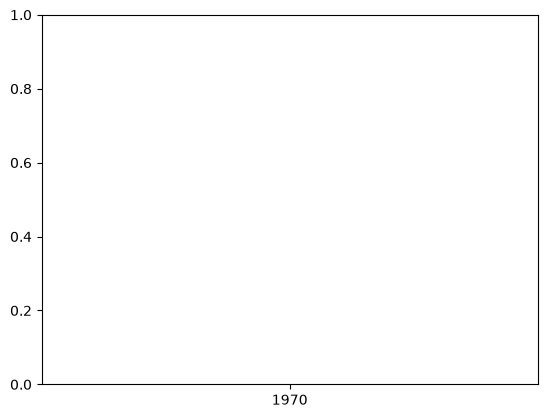

In [4]:
sr_one = df_daegu.loc['경상북도']

plt.plot(sr_one.index, sr_one.values, linestyle='--')

plt.title('대구 -> 경북 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

from matplotlib import font_manager, rc
font_path = './data/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font',family=font_name)

plt.style.use('ggplot')

plt.figure(figsize=(14,5))
plt.xticks(size=10,rotation='vertical')

plt.plot(sr_one.index, sr_one.values,
         marker='o',
         markerfacecolor='red',
         markeredgecolor='blue',
         markeredgewidth=2,
         markersize=10)

plt.title('대구 -> 경북 인구 이동', size=30)
plt.xlabel('기간',size=20)
plt.ylabel('이동 인구수',size=20)

plt.legend(labels=['대구 -> 경북'], loc='best', fontsize=15)

plt.show()


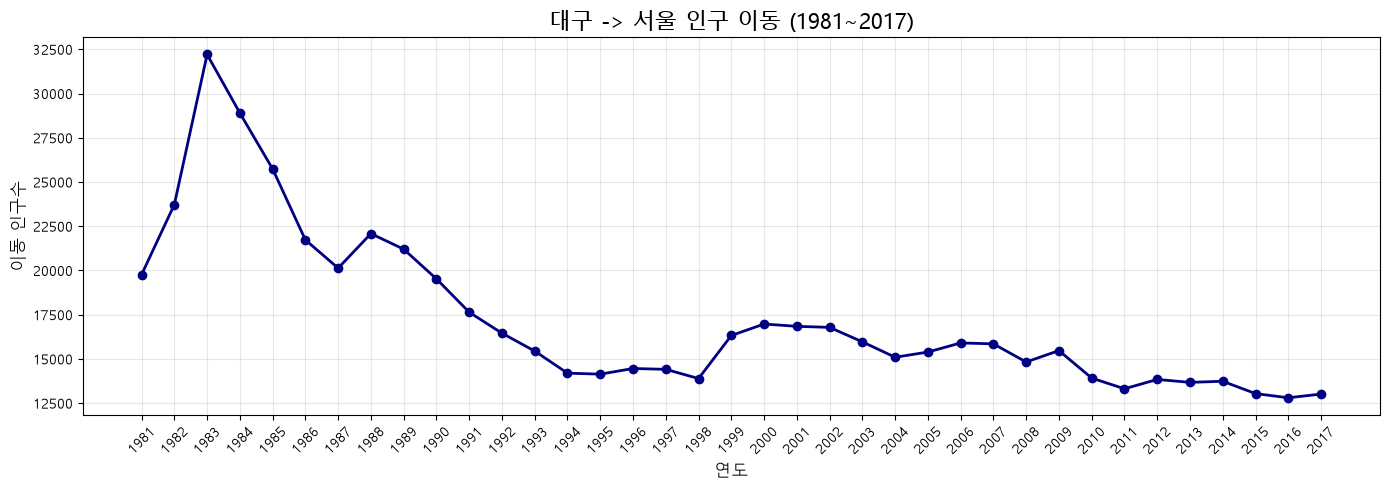

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

path = './data/시도별_전출입_인구수.xlsx'
df = pd.read_excel(path).ffill()

# 1981년 이후 연도만 선택
year_cols = [col for col in df.columns if col.isdigit() and 1981 <= int(col) <= 2017]
df = df[['전출지별', '전입지별'] + year_cols].copy()

# 문자열 값 정리 후 숫자로 변환
for col in year_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False).str.replace('-', '0'),
        errors='coerce'
    )

# 대구 -> 서울 데이터만 선택
mask = (df['전출지별'].astype(str).str.strip() == '대구광역시') & (df['전입지별'].astype(str).str.strip() == '서울특별시')
df_daegu_seoul = df.loc[mask].copy()

if df_daegu_seoul.empty:
    raise ValueError('대구광역시 -> 서울특별시 데이터가 없습니다.')

df_daegu_seoul = df_daegu_seoul.drop(columns=['전출지별']).rename(columns={'전입지별': '전입지'}).set_index('전입지')
sr_seoul = df_daegu_seoul.loc['서울특별시']
sr_seoul.index = year_cols
sr_seoul = sr_seoul.astype(float)

from matplotlib import font_manager, rc
font_path = './data/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font',family=font_name)

plt.figure(figsize=(14, 5))
plt.plot(sr_seoul.index, sr_seoul.values, marker='o', linewidth=2, color='navy')
plt.title('대구 -> 서울 인구 이동 (1981~2017)', size=16)
plt.xlabel('연도', size=12)
plt.ylabel('이동 인구수', size=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
